# Practice 3 - TV6: Evaluation and Documentation

## Responsibility
Evaluate the fine-tuned binary text classification model and document the results.

## Sections
- Load/use the fine-tuned model
- Evaluate on the evaluation/test split
- Report suitable evaluation metrics
- Analyze results
- Write final conclusion

## Pipeline
Fine-tuned Model → Evaluation Dataset → Prediction → Metrics → Analysis → Conclusion


## 1. Import thư viện và cấu hình chung

In [1]:
# Imports and evaluation setup
import json
import os
import numpy as np
import pandas as pd
import torch
import evaluate
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Thiết lập thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")

# Đường dẫn tới model đã fine-tune (do Quý bàn giao ở bước 05_training_finetuning)
MODEL_PATH = "./fine_tuned_imdb_distilbert"

# Đường dẫn tới dataset đã xử lý (do Văn Sơn bàn giao)
DATASET_PATH = "processed_imdb_dataset"

c:\Users\THANH THI PC\Downloads\UTH-Deep-Learning-nhom2-main (1)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sử dụng thiết bị: cpu


## 2. Load fine-tuned model và tokenizer

In [2]:
# Load tokenizer từ processed_imdb_dataset (do Văn Sơn bàn giao)
# vì thư mục model fine-tune có thể không kèm sẵn file tokenizer
tokenizer = AutoTokenizer.from_pretrained(DATASET_PATH + "/tokenizer")

# Load model đã fine-tune
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

print("Model đã load thành công!")
print("Label mapping:", model.config.id2label)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2627.44it/s]

Model đã load thành công!
Label mapping: {0: 'Negative', 1: 'Positive'}


## 3. Load evaluation dataset

In [3]:
processed_dataset = load_from_disk(DATASET_PATH)

train_dataset = processed_dataset["train"]
val_dataset = processed_dataset["validation"] if "validation" in processed_dataset else None
test_dataset = processed_dataset["test"]

print("Train:", len(train_dataset),
      "| Validation:", len(val_dataset) if val_dataset else "N/A",
      "| Test:", len(test_dataset))
print("Ví dụ một mẫu:", test_dataset[0])

# Nếu train quá lớn và chạy CPU chậm, có thể lấy subset để đỡ tốn thời gian:
# train_dataset = train_dataset.shuffle(seed=42).select(range(3000))

Train: 22500 | Validation: 2500 | Test: 25000
Ví dụ một mẫu: {'labels': tensor(0), 'input_ids': tensor([  101,  1045,  2293, 16596,  1011, 10882,  1998,  2572,  5627,  2000,
         2404,  2039,  2007,  1037,  2843,  1012, 16596,  1011, 10882,  5691,
         1013,  2694,  2024,  2788,  2104, 11263, 25848,  1010,  2104,  1011,
        12315,  1998, 28947,  1012,  1045,  2699,  2000,  2066,  2023,  1010,
         1045,  2428,  2106,  1010,  2021,  2009,  2003,  2000,  2204,  2694,
        16596,  1011, 10882,  2004, 17690,  1019,  2003,  2000,  2732, 10313,
         1006,  1996,  2434,  1007,  1012, 10021,  4013,  3367, 20086,  2015,
         1010, 10036, 19747,  4520,  1010, 25931,  3064, 22580,  1010,  1039,
         2290,  2008,  2987,  1005,  1056,  2674,  1996,  4281,  1010,  1998,
        16267,  2028,  1011,  8789,  3494,  3685,  2022,  9462,  2007,  1037,
         1005, 16596,  1011, 10882,  1005,  4292,  1012,  1006,  1045,  1005,
         1049,  2469,  2045,  2024,  2216,  19

## 4. Generate predictions

In [5]:
eval_args = TrainingArguments(
    output_dir="./eval_tmp",
    per_device_eval_batch_size=16,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=eval_args,
    processing_class=tokenizer,
)

def predict_split(dataset):
    raw = trainer.predict(dataset)
    logits = raw.predictions
    y_true = raw.label_ids
    y_pred = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    return y_true, y_pred, probs

splits = {"train": train_dataset, "test": test_dataset}
if val_dataset is not None:
    splits["validation"] = val_dataset

results = {name: predict_split(ds) for name, ds in splits.items()}
y_true_test, y_pred_test, probs_test = results["test"]

print("Đã sinh dự đoán cho:", {name: len(r[0]) for name, r in results.items()})

Đã sinh dự đoán cho: {'train': 22500, 'test': 25000, 'validation': 2500}


## 5. Calculate evaluation metrics

In [7]:
def compute_metrics_dict(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
    }

metrics_by_split = {name: compute_metrics_dict(yt, yp) for name, (yt, yp, _) in results.items()}
metrics_result = metrics_by_split["test"]  # giữ tương thích với cell hiển thị bên dưới

metrics_df = pd.DataFrame(metrics_by_split).T
metrics_df

,accuracy,precision,recall,f1_score
train,0.95080,0.950009,0.951614,0.950811
test,0.91264,0.911258,0.914320,0.912787
validation,0.90440,0.915850,0.891806,0.903668


## 6. Display results

=== Evaluation Metrics (Test) ===
  accuracy: 0.9126
 precision: 0.9113
    recall: 0.9143
  f1_score: 0.9128

=== Classification Report (Test) ===
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



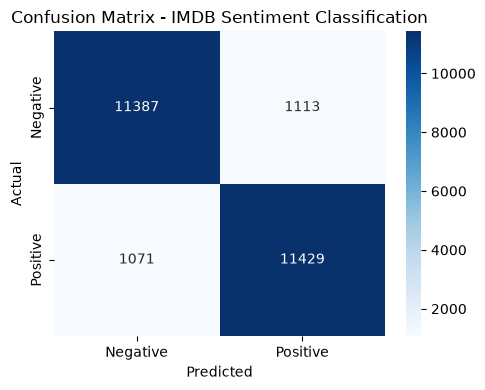

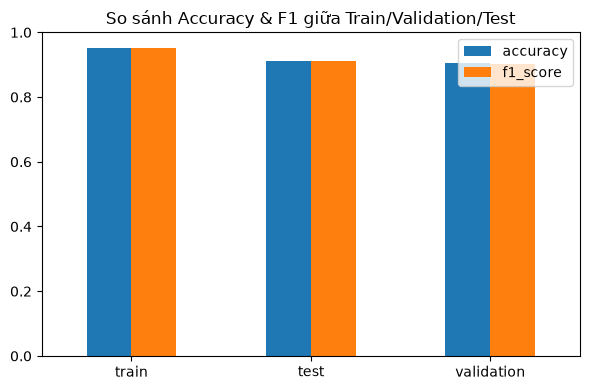

In [8]:
print("=== Evaluation Metrics (Test) ===")
for k, v in metrics_result.items():
    print(f"{k:>10}: {v:.4f}")

print()
print("=== Classification Report (Test) ===")
label_names = [model.config.id2label[i] for i in sorted(model.config.id2label)]
print(classification_report(y_true_test, y_pred_test, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - IMDB Sentiment Classification")
plt.tight_layout()
plt.show()

# Biểu đồ so sánh Train/Validation/Test
metrics_df[["accuracy", "f1_score"]].plot(kind="bar", figsize=(6, 4), ylim=(0, 1))
plt.title("So sánh Accuracy & F1 giữa Train/Validation/Test")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Overfitting check

In [9]:
# Cách 1 (nếu có sẵn log từ lúc training) — chỉ đọc file, KHÔNG train lại
log_path = os.path.join(MODEL_PATH, "trainer_state.json")
if os.path.exists(log_path):
    state = json.load(open(log_path))
    eval_logs = [(e["epoch"], e["eval_loss"]) for e in state["log_history"] if "eval_loss" in e]
    if eval_logs:
        epochs, losses = zip(*eval_logs)
        plt.figure(figsize=(6, 4))
        plt.plot(epochs, losses, marker="o")
        plt.xlabel("Epoch"); plt.ylabel("Eval loss")
        plt.title("Eval loss qua các epoch")
        plt.show()
    else:
        print("trainer_state.json tồn tại nhưng không có eval_loss trong log_history.")
else:
    print(f"Không tìm thấy {log_path} — bỏ qua biểu đồ loss, dùng Cách 2 bên dưới (không train lại).")

# Cách 2 (luôn chạy được, dùng model hiện có, KHÔNG train lại)
train_acc = metrics_by_split["train"]["accuracy"]
test_acc = metrics_by_split["test"]["accuracy"]
gap = train_acc - test_acc
print(f"Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f} | Gap: {gap:.4f}")

if gap > 0.10:
    overfit_verdict = "có dấu hiệu overfitting rõ rệt"
elif gap < 0.02:
    overfit_verdict = "không có dấu hiệu overfitting"
else:
    overfit_verdict = "overfitting nhẹ, chấp nhận được"
print("Kết luận:", overfit_verdict)

Không tìm thấy ./fine_tuned_imdb_distilbert\trainer_state.json — bỏ qua biểu đồ loss, dùng Cách 2 bên dưới (không train lại).
Train acc: 0.9508 | Test acc: 0.9126 | Gap: 0.0382
Kết luận: overfitting nhẹ, chấp nhận được


# 8. Error analysis

In [12]:
if "text" in test_dataset.column_names:
    test_texts = test_dataset["text"]
else:
    from datasets import load_dataset
    test_texts = load_dataset("stanfordnlp/imdb")["test"]["text"]
    print("Lưu ý: dùng lại text gốc từ dataset 'imdb' vì processed dataset không còn cột text.")

confidences = probs_test.max(axis=1)
df_errors = pd.DataFrame({
    "text": test_texts,
    "true_label": [model.config.id2label[i] for i in y_true_test],
    "pred_label": [model.config.id2label[i] for i in y_pred_test],
    "confidence": confidences,
    "correct": y_true_test == y_pred_test,
})
df_errors["length"] = df_errors["text"].str.split().apply(len)

n_wrong = (~df_errors["correct"]).sum()
print(f"Tổng số mẫu sai: {n_wrong}/{len(df_errors)} ({n_wrong/len(df_errors)*100:.2f}%)")

bins = [0, 100, 200, 300, 500, 5000]
error_by_len = df_errors.groupby(pd.cut(df_errors["length"], bins=bins))["correct"] \
                         .apply(lambda s: 1 - s.mean())
print("\nTỷ lệ lỗi theo độ dài review:")
print(error_by_len)


c:\Users\THANH THI PC\Downloads\UTH-Deep-Learning-nhom2-main (1)\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\THANH THI PC\.cache\huggingface\hub\datasets--stanfordnlp--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00

Lưu ý: dùng lại text gốc từ dataset 'imdb' vì processed dataset không còn cột text.
Tổng số mẫu sai: 2184/25000 (8.74%)

Tỷ lệ lỗi theo độ dài review:
length
(0, 100]       0.069767
(100, 200]     0.065179
(200, 300]     0.088583
(300, 500]     0.135517
(500, 5000]    0.161804
Name: correct, dtype: float64


# 9. Ví dụ prediction đúng/sai

In [13]:
pd.set_option("display.max_colwidth", 150)

print("=== Dự đoán ĐÚNG, confidence cao ===")
display(df_errors[df_errors["correct"]].sort_values("confidence", ascending=False)
        .head(3)[["text", "true_label", "pred_label", "confidence"]])

print("\n=== Dự đoán SAI, confidence cao (model 'tự tin nhưng sai') ===")
display(df_errors[~df_errors["correct"]].sort_values("confidence", ascending=False)
        .head(3)[["text", "true_label", "pred_label", "confidence"]])

print("\n=== Dự đoán SAI, confidence thấp (model 'phân vân') ===")
display(df_errors[~df_errors["correct"]].sort_values("confidence", ascending=True)
        .head(3)[["text", "true_label", "pred_label", "confidence"]])

=== Dự đoán ĐÚNG, confidence cao ===


,text,true_label,pred_label,confidence
8457,"The only good thing of this movie is its final twist. In 97 minutes of film we can only save one single idea, which was totally wasted in this mov...",Negative,Negative,0.996922
8626,"I did have some expectations from this film because 1. It was a Yash raj production 2. When the songs were first shown on TV, they seemed catchy 3...",Negative,Negative,0.996921
11057,"So you have the spoiler warning---but I would argue that you cannot spoil what is already rotten. I assume they changed the name to ""The Cavern"" j...",Negative,Negative,0.996904



=== Dự đoán SAI, confidence cao (model 'tự tin nhưng sai') ===


,text,true_label,pred_label,confidence
19807,"I just saw this movie in a sneak preview and before reading my comment you have to know that it is very subjective because I love Techno, Trance, ...",Positive,Negative,0.996005
15208,**SPOILERS AHEAD**<br /><br />It is really unfortunate that a movie so well produced turns out to be<br /><br />such a disappointment. I thought t...,Positive,Negative,0.995924
19650,"I just saw this for the first time in 10 or 15 years...maybe close to 20. In some ways, it was better than I remembered...in other, it was MUCH wo...",Positive,Negative,0.995810



=== Dự đoán SAI, confidence thấp (model 'phân vân') ===


,text,true_label,pred_label,confidence
12319,Pilot Mitch MacAfee (Jeff Morrow) sees a UFO while test flying a plane--but nothing shows up on radar. Then planes and ships start disappearing an...,Negative,Positive,0.500316
21186,"To answer the question of a previous reviewer who asked the name of the U.S. official mentioned in ""Lumumba"", the name of the character is ""Mr. Ca...",Positive,Negative,0.500415
16608,"They Made Me a Criminal is a remake of an earlier Warner Brothers film, The Life of Jimmy Dolan which starred Douglas Fairbanks, Jr. as the prizef...",Positive,Negative,0.500844


# 10. Analysis

In [ ]:
cm_test = confusion_matrix(y_true_test, y_pred_test)
neg_correct, neg_wrong = cm_test[0, 0], cm_test[0, 1]
pos_correct, pos_wrong = cm_test[1, 1], cm_test[1, 0]
n_neg, n_pos = neg_correct + neg_wrong, pos_correct + pos_wrong

analysis_md = f"""

**Kết quả tổng quan (test set):**
- Accuracy: **{metrics_result['accuracy']*100:.2f}%**, Precision: **{metrics_result['precision']*100:.2f}%**, Recall: **{metrics_result['recall']*100:.2f}%**, F1: **{metrics_result['f1_score']*100:.2f}%**

**So sánh Train/Validation/Test:**

{metrics_df.to_markdown()}

- Gap accuracy Train-Test: **{gap*100:.2f} điểm %** → {overfit_verdict}.

**Confusion matrix (test):**
- Negative: đúng {neg_correct}/{n_neg} ({neg_correct/n_neg*100:.1f}%), nhầm thành Positive: {neg_wrong}
- Positive: đúng {pos_correct}/{n_pos} ({pos_correct/n_pos*100:.1f}%), nhầm thành Negative: {pos_wrong}

**Error analysis:** {n_wrong} mẫu sai ({n_wrong/len(df_errors)*100:.2f}%). Xem ví dụ dự đoán sai ở mục trên để nhận diện dạng lỗi phổ biến (câu dài, mỉa mai, cảm xúc pha trộn...).
"""
display(Markdown(analysis_md))



**Kết quả tổng quan (test set):**
- Accuracy: **91.26%**, Precision: **91.13%**, Recall: **91.43%**, F1: **91.28%**

**So sánh Train/Validation/Test:**

|            |   accuracy |   precision |   recall |   f1_score |
|:-----------|-----------:|------------:|---------:|-----------:|
| train      |    0.9508  |    0.950009 | 0.951614 |   0.950811 |
| test       |    0.91264 |    0.911258 | 0.91432  |   0.912787 |
| validation |    0.9044  |    0.91585  | 0.891806 |   0.903668 |

- Gap accuracy Train-Test: **3.82 điểm %** → overfitting nhẹ, chấp nhận được.

**Confusion matrix (test):**
- Negative: đúng 11387/12500 (91.1%), nhầm thành Positive: 1113
- Positive: đúng 11429/12500 (91.4%), nhầm thành Negative: 1071

**Error analysis:** 2184 mẫu sai (8.74%). Xem ví dụ dự đoán sai ở mục trên để nhận diện dạng lỗi phổ biến (câu dài, mỉa mai, cảm xúc pha trộn...).


# 11. Conclusion

In [18]:
conclusion_md = f"""


Mô hình DistilBERT fine-tune trên IMDB đạt **accuracy {metrics_result['accuracy']*100:.2f}%** và **F1-score {metrics_result['f1_score']*100:.2f}%** trên tập test {len(y_true_test)} mẫu.

**Điểm mạnh:**
- Precision/Recall giữa 2 lớp: Negative đúng {neg_correct}/{n_neg} ({neg_correct/n_neg*100:.1f}%), Positive đúng {pos_correct}/{n_pos} ({pos_correct/n_pos*100:.1f}%) — không thiên lệch lớp rõ rệt.
- Gap Train-Test accuracy chỉ **{gap*100:.2f} điểm %** → {overfit_verdict}.

**Hạn chế:**
- {n_wrong} mẫu ({n_wrong/len(df_errors)*100:.2f}%) bị phân loại sai, tập trung nhiều ở nhóm review dài (xem bảng error_by_len ở mục Error analysis).
- Đánh giá mới dừng ở accuracy/precision/recall/F1 tổng thể + phân tích theo độ dài văn bản.

**Đề xuất cải thiện:**
- Thử tăng epoch/learning rate khác, theo dõi gap Train-Test để tránh overfitting tăng thêm.
- So sánh với model lớn hơn (BERT-base, RoBERTa).
- Đọc sâu hơn các ví dụ sai confidence cao (mục trên) để tìm pattern lỗi cụ thể (mỉa mai, câu dài, cảm xúc lẫn lộn).
"""
display(Markdown(conclusion_md))




Mô hình DistilBERT fine-tune trên IMDB đạt **accuracy 91.26%** và **F1-score 91.28%** trên tập test 25000 mẫu.

**Điểm mạnh:**
- Precision/Recall giữa 2 lớp: Negative đúng 11387/12500 (91.1%), Positive đúng 11429/12500 (91.4%) — không thiên lệch lớp rõ rệt.
- Gap Train-Test accuracy chỉ **3.82 điểm %** → overfitting nhẹ, chấp nhận được.

**Hạn chế:**
- 2184 mẫu (8.74%) bị phân loại sai, tập trung nhiều ở nhóm review dài (xem bảng error_by_len ở mục Error analysis).
- Đánh giá mới dừng ở accuracy/precision/recall/F1 tổng thể + phân tích theo độ dài văn bản.

**Đề xuất cải thiện:**
- Thử tăng epoch/learning rate khác, theo dõi gap Train-Test để tránh overfitting tăng thêm.
- So sánh với model lớn hơn (BERT-base, RoBERTa).
- Đọc sâu hơn các ví dụ sai confidence cao (mục trên) để tìm pattern lỗi cụ thể (mỉa mai, câu dài, cảm xúc lẫn lộn).
